# Results Plotting Notebook

This notebook consumes `results.pt` produced by `collect_results.py` and generates Figures 1 through 8.

Expected top-level keys:

```python
{
    "motivation": [...],
    "insight": [...],
    "trace": [...],
    "results": [...],
}
```


In [16]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.set_palette("tab10")
sns.set_style("whitegrid")
plt.rc("font", size=12)

# =========================
# User parameters
# =========================
RESULTS_PT = Path("./results.pt")
PLOTS_DIR = Path("./plots_results")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 16
SPECULATIVE_LENGTH = 3
HIERARCHICAL_ROUND = 1

# Figures 1-5 use the same batch size / speculative length configuration.
TRACE_SPECULATIVE_LENGTH = SPECULATIVE_LENGTH
TOPK_SPECULATIVE_LENGTH = SPECULATIVE_LENGTH
CONF_SPECULATIVE_LENGTH = SPECULATIVE_LENGTH

# Figure 5 explicitly requires k=3 and k=7 in the old script; kept for Figure 6+ compatibility.
INTRA_BATCH_SPECULATIVE_LENGTHS = [3, 7]

# Optional filters. Set to None to include everything.
METHOD_FILTER = None
DATASET_FILTER = None
TARGET_MODEL_FILTER = None
MODEL_PAIR_FILTER = None

# Pretty names for common methods.
METHOD_RENAME = {
    "ar": "AR",
    "autoregressive": "AR",
    "auto_regressive": "AR",
    "sync": "SD",
    "speculative_decoding": "SD",
    "speculative": "SD",
    "draft_model": "SD",
    "hierarchical": "HV",
    "hierarchical_verification": "HV",
    "hispec": "HV",
    "spechive": "HV",
    "eagle3": "Eagle3",
    "eagle": "Eagle3",
    "pivot": "Pivot",
    "pivot_hierarchical": "Pivot + HV",
}

DATASET_RENAME = {
    "alpaca": "Alpaca",
    "codeelo": "CodeELO",
    "gsm8k": "GSM8K",
    "math500": "Math500",
}

METHOD_ORDER = ["AR", "SD", "HV", "Eagle3", "Pivot", "Pivot + HV"]
DATASET_ORDER = ["Alpaca", "CodeELO", "GSM8K", "Math500"]
FIGURE_1_METHODS = ["AR", "SD", "HV", "Eagle3"]
FIGURE_2_4_METHODS = ["SD", "HV"]
FIGURE_5_METHODS = ["SD", "SD-Oracle", "HV", "HV-Oracle"]

# Match the attached notebook style.
FIGSIZE_WIDE = (8, 2)
FIGSIZE_TALL = (8, 2)
FIGSIZE_GRID = (8, 2.4)
DPI = 600


In [17]:
# =========================
# Load and normalize data
# =========================

data = torch.load(RESULTS_PT, map_location="cpu")

motivation_df = pd.DataFrame(data.get("motivation", []))
insight_df = pd.DataFrame(data.get("insight", []))
trace_df = pd.DataFrame(data.get("trace", []))
results_df = pd.DataFrame(data.get("results", []))

def normalize_common_columns(df):
    if df.empty:
        return df.copy()

    out = df.copy()

    if "speculate_k" in out.columns and "speculative_length" not in out.columns:
        out = out.rename(columns={"speculate_k": "speculative_length"})

    if "method" in out.columns:
        out["method_pretty"] = out["method"].map(METHOD_RENAME).fillna(out["method"])

    if "dataset" in out.columns:
        out["dataset"] = out["dataset"].astype(str).map(lambda x: DATASET_RENAME.get(x.lower(), x))

    if "target_model" in out.columns and "draft_model" in out.columns:
        out["model_pair"] = out["target_model"].astype(str) + "+" + out["draft_model"].astype(str)
    else:
        out["model_pair"] = "unknown"

    if "target_model" not in out.columns:
        out["target_model"] = out["model_pair"].astype(str).str.split("+").str[0]

    if "batch_size" in out.columns:
        out = out[out["batch_size"] == BATCH_SIZE]

    # Hierarchical runs are stored under .../t0/r{round}/dataset.
    # Keep the selected round while leaving non-hierarchical rows untouched.
    if "round" in out.columns and "method_pretty" in out.columns:
        out = out[(out["method_pretty"] != "HV") | (out["round"].fillna(HIERARCHICAL_ROUND) == HIERARCHICAL_ROUND)]

    if METHOD_FILTER is not None and "method" in out.columns:
        out = out[out["method"].isin(METHOD_FILTER)]

    if DATASET_FILTER is not None and "dataset" in out.columns:
        out = out[out["dataset"].isin(DATASET_FILTER)]

    if TARGET_MODEL_FILTER is not None and "target_model" in out.columns:
        out = out[out["target_model"].isin(TARGET_MODEL_FILTER)]

    if MODEL_PAIR_FILTER is not None and "model_pair" in out.columns:
        out = out[out["model_pair"].isin(MODEL_PAIR_FILTER)]

    return out

motivation_df = normalize_common_columns(motivation_df)
insight_df = normalize_common_columns(insight_df)
trace_df = normalize_common_columns(trace_df)
results_df = normalize_common_columns(results_df)

def method_sort_key(method):
    if method in METHOD_ORDER:
        return METHOD_ORDER.index(method)
    return len(METHOD_ORDER)

def sorted_methods(methods):
    return sorted(methods, key=method_sort_key)

def dataset_sort_key(dataset):
    dataset = str(dataset)
    if dataset in DATASET_ORDER:
        return (0, DATASET_ORDER.index(dataset))
    return (1, dataset)

def sorted_datasets(datasets):
    return sorted([d for d in datasets if pd.notna(d)], key=dataset_sort_key)

def sorted_model_pairs(*dfs):
    pairs = set()
    for df in dfs:
        if not df.empty and "model_pair" in df.columns:
            pairs.update(df["model_pair"].dropna().unique().tolist())
    return sorted(pairs)

def sorted_target_models(*dfs):
    targets = set()
    for df in dfs:
        if not df.empty and "target_model" in df.columns:
            targets.update(df["target_model"].dropna().astype(str).unique().tolist())
    return sorted(targets)

model_pairs = sorted_model_pairs(motivation_df, insight_df, trace_df, results_df)
target_models = sorted_target_models(motivation_df, insight_df, trace_df, results_df)

print("Loaded:")
print(f"  motivation rows: {len(motivation_df)}")
print(f"  insight rows:    {len(insight_df)}")
print(f"  trace rows:      {len(trace_df)}")
print(f"  results rows:    {len(results_df)}")
print(f"  target models:   {len(target_models)}")
print(f"  model pairs:     {len(model_pairs)}")
display(pd.DataFrame({"target_model": target_models}))


Loaded:
  motivation rows: 49
  insight rows:    49
  trace rows:      49
  results rows:    60
  target models:   2
  model pairs:     4


,target_model
0,Llama-3.3-70B-Instruct
1,Qwen3-32B


In [18]:
# =========================
# Plot helpers
# =========================

palette = sns.color_palette("tab10")

FIXED_COLORS = {
    "Target Verification": palette[0],
    "Intermediate Verification": palette[1],
    "Draft": palette[2],
    "Others": palette[3],
    "AR": palette[0],
    "SD": palette[1],
    "HV": palette[2],
    "Eagle3": palette[3],
    "SD-Oracle": palette[4],
    "HV-Oracle": palette[5],
}

def color_map(labels):
    return {label: FIXED_COLORS.get(label, palette[i % len(palette)]) for i, label in enumerate(labels)}

def safe_name(name):
    return (
        str(name)
        .replace("/", "__")
        .replace("+", "__PLUS__")
        .replace(" ", "_")
        .replace(":", "_")
    )

def save_fig(fig, out_dir, basename):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = out_dir / f"{basename}.pdf"
    png_path = out_dir / f"{basename}.png"

    fig.savefig(pdf_path, bbox_inches="tight", dpi=DPI)
    fig.savefig(png_path, bbox_inches="tight", dpi=DPI)
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")

def style_axis(ax, xlabel=None, ylabel=None, grid_axis="y"):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True, linestyle=":", axis=grid_axis)

def legend_top(ax, ncol, y=1.25, fontsize=11):
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        fancybox=True,
        shadow=False,
        fontsize=fontsize,
        frameon=True,
    )

def get_model_out_dir(model_pair):
    out_dir = PLOTS_DIR / safe_name(model_pair)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir

def get_target_out_dir(target_model):
    out_dir = PLOTS_DIR / safe_name(target_model)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir

def nonempty(df, required_cols, fig_name):
    if df.empty:
        print(f"[skip] {fig_name}: empty dataframe")
        return False
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"[skip] {fig_name}: missing columns {missing}")
        return False
    return True

def aggregate_mean(df, group_cols, value_col):
    return (
        df.dropna(subset=[value_col])
        .groupby(group_cols, as_index=False)[value_col]
        .mean()
        .sort_values(group_cols)
    )

def first_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def require_any_col(df, candidates, fig_name):
    col = first_existing_col(df, candidates)
    if col is None:
        print(f"[skip] {fig_name}: missing any of columns {candidates}")
    return col

def row_number(row, col, default=0.0):
    if col is None:
        return default
    val = row.get(col, default)
    if pd.isna(val):
        return default
    return float(val)

def filter_target_and_k(df, target_model, methods=None, k=SPECULATIVE_LENGTH):
    out = df[df["target_model"].astype(str) == str(target_model)].copy()
    if methods is not None:
        out = out[out["method_pretty"].isin(methods)].copy()
    if "speculative_length" in out.columns:
        # AR uses k=na; keep it explicitly. Non-AR must match k.
        out = out[(out["method_pretty"] == "AR") | (out["speculative_length"] == k)].copy()
    return out

def trace_row_to_series(row):
    values = row.get("target_accept_len_by_request")
    rows = []

    if isinstance(values, dict):
        for request, seq in values.items():
            if not isinstance(seq, (list, tuple, np.ndarray)):
                continue
            for step_id, val in enumerate(seq):
                rows.append({"request": request, "step_id": step_id, "target_accept_len": val})
    elif isinstance(values, (list, tuple, np.ndarray)):
        if len(values) > 0 and isinstance(values[0], (list, tuple, np.ndarray)):
            for request, seq in enumerate(values):
                for step_id, val in enumerate(seq):
                    rows.append({"request": request, "step_id": step_id, "target_accept_len": val})
        else:
            for step_id, val in enumerate(values):
                rows.append({"request": 0, "step_id": step_id, "target_accept_len": val})

    return pd.DataFrame(rows)

def topk_dict_to_row(d):
    if not isinstance(d, dict):
        return {}
    out = {}
    for k in range(2, 6):
        for key in (f"top{k}_prob", f"top_{k}_prob", f"top{k}", f"top_{k}"):
            if key in d:
                out[f"top{k}_prob"] = d[key]
                break
    return out


## Figure 1. Normalized throughput breakdown by dataset and method

saved: plots_results/Llama-3.3-70B-Instruct/figure_1_normalized_throughput_breakdown_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct/figure_1_normalized_throughput_breakdown_k3.png


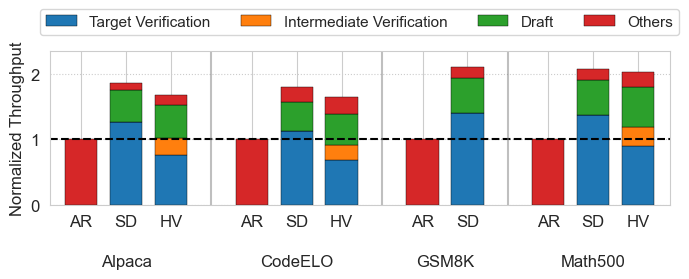

saved: plots_results/Qwen3-32B/figure_1_normalized_throughput_breakdown_k3.pdf
saved: plots_results/Qwen3-32B/figure_1_normalized_throughput_breakdown_k3.png


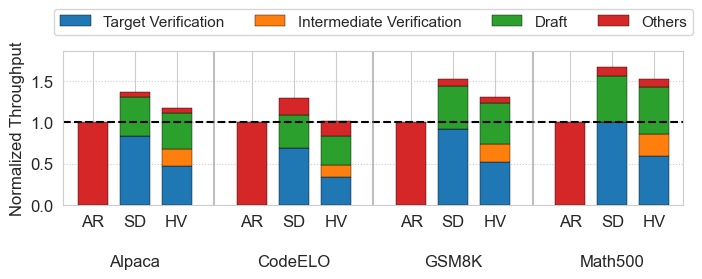

In [19]:
def build_figure_1_rows_for_target(target_model):
    fig_name = "figure_1_normalized_throughput_breakdown"
    if not nonempty(results_df, ["target_model", "method_pretty", "dataset", "execution_wall_time_s"], fig_name):
        return pd.DataFrame()

    df = filter_target_and_k(results_df, target_model, methods=FIGURE_1_METHODS, k=SPECULATIVE_LENGTH)
    if df.empty:
        return pd.DataFrame()

    agg_cols = ["execution_wall_time_s"]
    for col in [
        "draft_time_s",
        "verification_time_s",
        "hierarchical_intermediate_verification_time_s",
        "hierarchical_target_verification_time_s",
    ]:
        if col in df.columns:
            agg_cols.append(col)

    # Critical fix: aggregate by target_model, dataset, and method, not by model_pair.
    # AR is target+none, while SD/HV/Eagle3 normally use target+draft. Grouping by model_pair
    # isolates AR and produces AR-only plots.
    agg = df.groupby(["dataset", "method_pretty"], as_index=False)[agg_cols].mean()

    rows = []
    for dataset in sorted_datasets(agg["dataset"].unique()):
        ar_rows = agg[(agg["dataset"] == dataset) & (agg["method_pretty"] == "AR")]
        if ar_rows.empty:
            print(f"[skip] {fig_name}: no AR baseline for dataset={dataset}, target_model={target_model}")
            continue
        ar_time = float(ar_rows["execution_wall_time_s"].iloc[0])
        if not np.isfinite(ar_time) or ar_time <= 0:
            continue

        for method in FIGURE_1_METHODS:
            sub = agg[(agg["dataset"] == dataset) & (agg["method_pretty"] == method)]
            if sub.empty:
                continue
            row = sub.iloc[0]
            total_time = float(row["execution_wall_time_s"])
            if not np.isfinite(total_time) or total_time <= 0:
                continue

            normalized_throughput = ar_time / total_time
            if method == "AR":
                rows.append({
                    "dataset": dataset,
                    "method": method,
                    "Target Verification": 0.0,
                    "Intermediate Verification": 0.0,
                    "Draft": 0.0,
                    "Others": 1.0,
                    "normalized_throughput": 1.0,
                })
                continue

            draft = row_number(row, "draft_time_s")
            if method == "HV":
                target = row_number(row, "hierarchical_target_verification_time_s", row_number(row, "verification_time_s"))
                intermediate = row_number(row, "hierarchical_intermediate_verification_time_s")
                others = total_time - draft - target - intermediate
            else:
                target = row_number(row, "verification_time_s")
                intermediate = 0.0
                others = total_time - draft - target
            others = max(0.0, others)

            rows.append({
                "dataset": dataset,
                "method": method,
                "Target Verification": normalized_throughput * target / total_time,
                "Intermediate Verification": normalized_throughput * intermediate / total_time,
                "Draft": normalized_throughput * draft / total_time,
                "Others": normalized_throughput * others / total_time,
                "normalized_throughput": normalized_throughput,
            })
    return pd.DataFrame(rows)


def plot_figure_1_normalized_throughput_breakdown():
    fig_name = "figure_1_normalized_throughput_breakdown"
    cost_cols = ["Target Verification", "Intermediate Verification", "Draft", "Others"]
    cost_labels = ["Target Verification", "Intermediate Verification", "Draft", "Others"]
    cost_colors = color_map(cost_labels)

    for target_model in target_models:
        plot_df = build_figure_1_rows_for_target(target_model)
        if plot_df.empty:
            print(f"[skip] {fig_name}: no rows for {target_model}")
            continue

        datasets = sorted_datasets(plot_df["dataset"].unique())
        methods = [m for m in FIGURE_1_METHODS if m in plot_df["method"].unique()]

        fig, ax = plt.subplots(figsize=(8, 2))
        width = 0.72
        cursor = 0.0
        tick_positions = []
        tick_labels = []
        centers = []
        boundary_positions = []

        for dataset in datasets:
            present = [m for m in methods if not plot_df[(plot_df["dataset"] == dataset) & (plot_df["method"] == m)].empty]
            xs = []
            for method in present:
                row = plot_df[(plot_df["dataset"] == dataset) & (plot_df["method"] == method)].iloc[0]
                bottom = 0.0
                for cost in cost_cols:
                    val = float(row[cost])
                    ax.bar(
                        cursor,
                        val,
                        width=width,
                        bottom=bottom,
                        label=cost,
                        color=cost_colors[cost],
                        edgecolor="black",
                        linewidth=0.3,
                    )
                    bottom += val
                tick_positions.append(cursor)
                tick_labels.append(method)
                xs.append(cursor)
                cursor += 1.0
            if xs:
                centers.append((dataset, float(np.mean(xs))))
                boundary_positions.append(cursor - 0.5)
                cursor += 0.8

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        style_axis(ax, ylabel="Normalized Throughput")
        ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5)

        for dataset, center in centers:
            ax.text(center, -0.32, dataset, ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=12)
        for b in boundary_positions[:-1]:
            ax.axvline(x=b + 0.4, color="grey", linestyle="-", alpha=0.5)

        ymax = max(1.05, plot_df["normalized_throughput"].max() * 1.12)
        ax.set_ylim(0.0, ymax)
        ax.set_xlim(-0.7, max(tick_positions) + 0.7)
        legend_top(ax, ncol=4, y=1.32, fontsize=11)
        save_fig(fig, get_target_out_dir(target_model), f"{fig_name}_k{SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_1_normalized_throughput_breakdown()


## Figure 2. Normalized number of target verification rounds

saved: plots_results/Llama-3.3-70B-Instruct/figure_2_normalized_target_verification_rounds_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct/figure_2_normalized_target_verification_rounds_k3.png


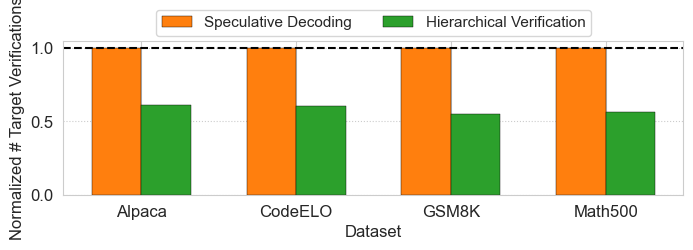

saved: plots_results/Qwen3-32B/figure_2_normalized_target_verification_rounds_k3.pdf
saved: plots_results/Qwen3-32B/figure_2_normalized_target_verification_rounds_k3.png


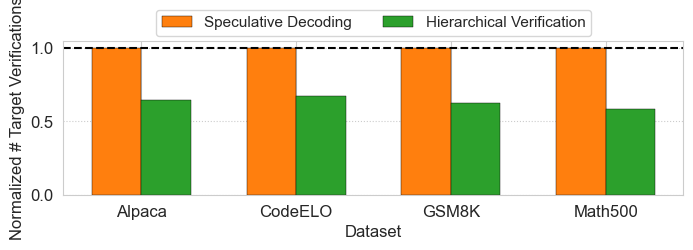

In [20]:
def plot_figure_2_normalized_target_verification_rounds():
    fig_name = "figure_2_normalized_target_verification_rounds"
    rounds_col = require_any_col(motivation_df, ["total_target_verification_rounds"], fig_name)
    if rounds_col is None or not nonempty(motivation_df, ["target_model", "method_pretty", "dataset", rounds_col], fig_name):
        return

    for target_model in target_models:
        df = filter_target_and_k(motivation_df, target_model, methods=FIGURE_2_4_METHODS, k=SPECULATIVE_LENGTH)
        if df.empty:
            print(f"[skip] {fig_name}: no SD/HV rows for {target_model}")
            continue

        agg = df.groupby(["dataset", "method_pretty"], as_index=False)[rounds_col].mean()
        datasets = sorted_datasets(agg["dataset"].unique())
        x = np.arange(len(datasets))
        width = 0.32
        colors = color_map(FIGURE_2_4_METHODS)

        fig, ax = plt.subplots(figsize=(8, 2))
        for i, method in enumerate(FIGURE_2_4_METHODS):
            vals = []
            for dataset in datasets:
                sd = agg[(agg["dataset"] == dataset) & (agg["method_pretty"] == "SD")]
                sub = agg[(agg["dataset"] == dataset) & (agg["method_pretty"] == method)]
                if sd.empty or sub.empty or float(sd[rounds_col].iloc[0]) <= 0:
                    vals.append(np.nan)
                else:
                    vals.append(float(sub[rounds_col].iloc[0]) / float(sd[rounds_col].iloc[0]))
            ax.bar(
                x + (i - 0.5) * width,
                vals,
                width=width,
                label={"SD": "Speculative Decoding", "HV": "Hierarchical Verification"}.get(method, method),
                color=colors[method],
                edgecolor="black",
                linewidth=0.3,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        style_axis(ax, xlabel="Dataset", ylabel="Normalized # Target Verifications")
        ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5)
        ax.set_ylim(0.0, max(1.05, ax.get_ylim()[1]))
        legend_top(ax, ncol=2, y=1.25)
        save_fig(fig, get_target_out_dir(target_model), f"{fig_name}_k{SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_2_normalized_target_verification_rounds()


## Figure 3. Acceptance length traces split by dataset

saved: plots_results/Llama-3.3-70B-Instruct/figure_3_acceptance_length_trace_by_dataset_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct/figure_3_acceptance_length_trace_by_dataset_k3.png


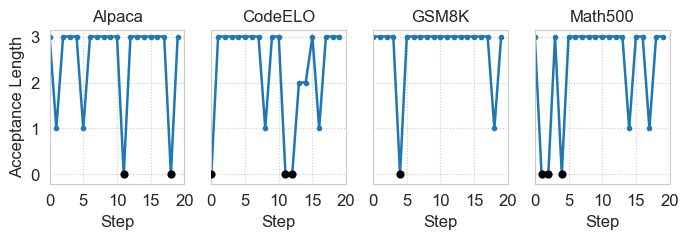

saved: plots_results/Qwen3-32B/figure_3_acceptance_length_trace_by_dataset_k3.pdf
saved: plots_results/Qwen3-32B/figure_3_acceptance_length_trace_by_dataset_k3.png


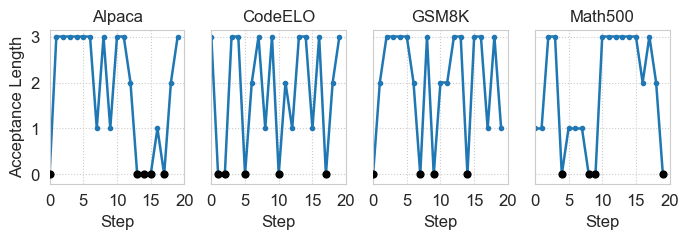

In [21]:
def plot_figure_3_acceptance_length_trace_by_dataset():
    fig_name = "figure_3_acceptance_length_trace_by_dataset"
    if not nonempty(trace_df, ["target_model", "method_pretty", "dataset", "speculative_length", "target_accept_len_by_request"], fig_name):
        return

    for target_model in target_models:
        df = filter_target_and_k(trace_df, target_model, methods=["SD"], k=SPECULATIVE_LENGTH)
        if df.empty:
            print(f"[skip] {fig_name}: no SD k={SPECULATIVE_LENGTH} rows for {target_model}")
            continue

        long_rows = []
        for _, row in df.iterrows():
            series_df = trace_row_to_series(row)
            if series_df.empty:
                continue
            series_df["dataset"] = row["dataset"]
            long_rows.append(series_df)
        if not long_rows:
            print(f"[skip] {fig_name}: no trace series for {target_model}")
            continue

        long_df = pd.concat(long_rows, ignore_index=True).dropna(subset=["target_accept_len"])
        datasets = [d for d in DATASET_ORDER if d in set(long_df["dataset"])]
        datasets += [d for d in sorted_datasets(long_df["dataset"].unique()) if d not in datasets]
        datasets = datasets[:4]

        fig, axes = plt.subplots(1, len(datasets), figsize=(8, 2), sharey=True)
        if len(datasets) == 1:
            axes = [axes]

        for ax, dataset in zip(axes, datasets):
            sub_all = long_df[long_df["dataset"] == dataset].copy()
            request = sorted(sub_all["request"].unique())[0]
            sub = sub_all[sub_all["request"] == request].sort_values("step_id")
            ax.plot(sub["step_id"], sub["target_accept_len"], marker="o", linewidth=1.8, markersize=3)
            miss = sub[sub["target_accept_len"] == 0]
            if not miss.empty:
                ax.scatter(miss["step_id"], miss["target_accept_len"], s=24, color="black", zorder=5)
            ax.set_title(dataset, fontsize=12)
            ax.set_xlabel("Step", fontsize=12)
            ax.set_xticks([0, 5, 10, 15, 20])
            ax.set_xlim(left=0, right=20)
            ax.set_ylim(bottom=-0.2)
            ax.tick_params(axis="both", which="major", labelsize=12)
            ax.grid(True, linestyle=":")
        axes[0].set_ylabel("Acceptance Length", fontsize=12)
        save_fig(fig, get_target_out_dir(target_model), f"{fig_name}_k{SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_3_acceptance_length_trace_by_dataset()


## Figure 4. Misspeculation probability by dataset

saved: plots_results/Llama-3.3-70B-Instruct/figure_4_misspeculation_probability_by_dataset_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct/figure_4_misspeculation_probability_by_dataset_k3.png


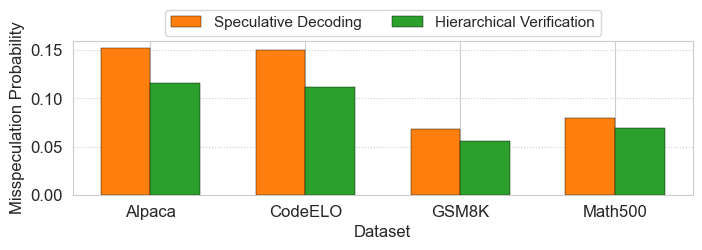

saved: plots_results/Qwen3-32B/figure_4_misspeculation_probability_by_dataset_k3.pdf
saved: plots_results/Qwen3-32B/figure_4_misspeculation_probability_by_dataset_k3.png


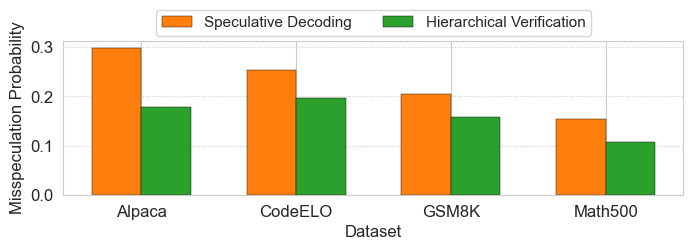

In [22]:
def plot_figure_4_misspeculation_probability_by_dataset():
    fig_name = "figure_4_misspeculation_probability_by_dataset"
    prob_col = require_any_col(motivation_df, ["misspeculation_probability"], fig_name)
    if prob_col is None or not nonempty(motivation_df, ["target_model", "method_pretty", "dataset", prob_col], fig_name):
        return

    for target_model in target_models:
        df = filter_target_and_k(motivation_df, target_model, methods=FIGURE_2_4_METHODS, k=SPECULATIVE_LENGTH)
        if df.empty:
            print(f"[skip] {fig_name}: no SD/HV rows for {target_model}")
            continue

        agg = df.groupby(["dataset", "method_pretty"], as_index=False)[prob_col].mean()
        datasets = sorted_datasets(agg["dataset"].unique())
        x = np.arange(len(datasets))
        width = 0.32
        colors = color_map(FIGURE_2_4_METHODS)
        fig, ax = plt.subplots(figsize=(8, 2))
        for i, method in enumerate(FIGURE_2_4_METHODS):
            vals = []
            for dataset in datasets:
                sub = agg[(agg["dataset"] == dataset) & (agg["method_pretty"] == method)]
                vals.append(np.nan if sub.empty else float(sub[prob_col].iloc[0]))
            ax.bar(
                x + (i - 0.5) * width,
                vals,
                width=width,
                label={"SD":"Speculative Decoding", "HV":"Hierarchical Verification"}.get(method, method),
                color=colors[method],
                edgecolor="black",
                linewidth=0.3,
            )
        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        style_axis(ax, xlabel="Dataset", ylabel="Misspeculation Probability")
        legend_top(ax, ncol=2, y=1.25)
        save_fig(fig, get_target_out_dir(target_model), f"{fig_name}_k{SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_4_misspeculation_probability_by_dataset()


## Figure 5. Oracle throughput after removing misspeculation rounds

saved: plots_results/Llama-3.3-70B-Instruct/figure_5_oracle_normalized_throughput_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct/figure_5_oracle_normalized_throughput_k3.png


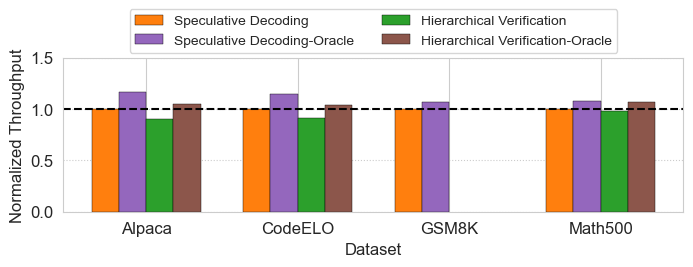

saved: plots_results/Qwen3-32B/figure_5_oracle_normalized_throughput_k3.pdf
saved: plots_results/Qwen3-32B/figure_5_oracle_normalized_throughput_k3.png


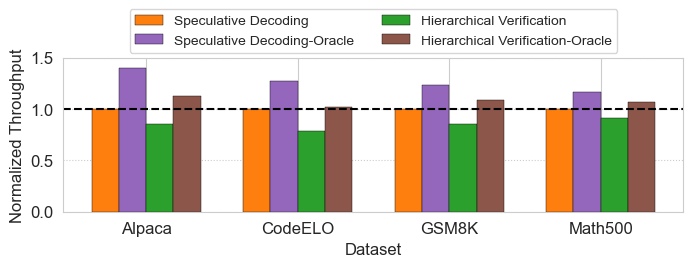

In [27]:
def plot_figure_5_oracle_normalized_throughput():
    fig_name = "figure_5_oracle_normalized_throughput"
    rounds_col = require_any_col(motivation_df, ["total_target_verification_rounds"], fig_name)
    prob_col = first_existing_col(motivation_df, ["misspeculation_probability"])
    miss_col = first_existing_col(motivation_df, ["misspeculation_rounds", "num_misspeculation_rounds", "total_misspeculation_rounds"])
    if rounds_col is None:
        return
    if not nonempty(results_df, ["target_model", "method_pretty", "dataset", "execution_wall_time_s"], fig_name):
        return

    cost_cols = [
        "execution_wall_time_s",
        "throughput",
        "num_decode_tokens",
        "draft_time_s",
        "verification_time_s",
        "hierarchical_intermediate_verification_time_s",
        "hierarchical_target_verification_time_s",
    ]
    existing_cost_cols = [c for c in cost_cols if c in results_df.columns]

    for target_model in target_models:
        mot = filter_target_and_k(motivation_df, target_model, methods=FIGURE_2_4_METHODS, k=SPECULATIVE_LENGTH)
        res = filter_target_and_k(results_df, target_model, methods=FIGURE_2_4_METHODS, k=SPECULATIVE_LENGTH)
        if mot.empty or res.empty:
            print(f"[skip] {fig_name}: missing motivation/results rows for {target_model}")
            continue

        mot_cols = [c for c in [rounds_col, prob_col, miss_col] if c is not None]
        mot_agg = mot.groupby(["dataset", "method_pretty"], as_index=False)[mot_cols].mean()
        res_agg = res.groupby(["dataset", "method_pretty"], as_index=False)[existing_cost_cols].mean()
        df = mot_agg.merge(res_agg, on=["dataset", "method_pretty"], how="inner")
        if df.empty:
            print(f"[skip] {fig_name}: no merged rows for {target_model}")
            continue

        rows = []
        for _, row in df.iterrows():
            method = row["method_pretty"]
            rounds = row_number(row, rounds_col)
            if miss_col is not None:
                miss_rounds = row_number(row, miss_col)
            elif prob_col is not None:
                miss_rounds = row_number(row, prob_col) * rounds
            else:
                miss_rounds = 0.0

            miss_frac = 0.0 if rounds <= 0 else np.clip(miss_rounds / rounds, 0.0, 0.999999)
            exec_time = row_number(row, "execution_wall_time_s")
            throughput = row_number(row, "throughput")
            decode_tokens = row_number(row, "num_decode_tokens", default=np.nan)

            if throughput <= 0 and np.isfinite(decode_tokens) and exec_time > 0:
                throughput = decode_tokens / exec_time

            rows.append({"dataset": row["dataset"], "method": method, "throughput": throughput})

            # Oracle removes misspeculation target-verification rounds.
            # For HV, intermediate verification rounds shrink by the same ratio as target rounds.
            if method == "HV":
                draft_time = row_number(row, "draft_time_s")
                target_time = row_number(row, "hierarchical_target_verification_time_s", row_number(row, "verification_time_s"))
                intermediate_time = row_number(row, "hierarchical_intermediate_verification_time_s")
                oracle_exec_time = exec_time - miss_frac * target_time - miss_frac * intermediate_time  - miss_frac * (2 * draft_time)
            else:
                draft_time = row_number(row, "draft_time_s")
                target_time = row_number(row, "verification_time_s")
                oracle_exec_time = exec_time - miss_frac * target_time - miss_frac * draft_time

            oracle_exec_time = max(1e-12, oracle_exec_time)
            if np.isfinite(decode_tokens) and decode_tokens > 0:
                oracle_throughput = decode_tokens / oracle_exec_time
            elif throughput > 0 and exec_time > 0:
                oracle_throughput = throughput * exec_time / oracle_exec_time
            else:
                oracle_throughput = np.nan

            rows.append({"dataset": row["dataset"], "method": f"{method}-Oracle", "throughput": oracle_throughput})

        plot_df = pd.DataFrame(rows)
        datasets = sorted_datasets(plot_df["dataset"].unique())
        x = np.arange(len(datasets))
        width = 0.18
        colors = color_map(FIGURE_5_METHODS)

        fig, ax = plt.subplots(figsize=(8, 2))
        for i, method in enumerate(FIGURE_5_METHODS):
            vals = []
            for dataset in datasets:
                sd = plot_df[(plot_df["dataset"] == dataset) & (plot_df["method"] == "SD")]
                sub = plot_df[(plot_df["dataset"] == dataset) & (plot_df["method"] == method)]
                if sd.empty or sub.empty or float(sd["throughput"].iloc[0]) <= 0:
                    vals.append(np.nan)
                else:
                    vals.append(float(sub["throughput"].iloc[0]) / float(sd["throughput"].iloc[0]))
            label = {
                "SD": "Speculative Decoding",
                "SD-Oracle": "Speculative Decoding-Oracle",
                "HV": "Hierarchical Verification",
                "HV-Oracle": "Hierarchical Verification-Oracle",
            }[method]
            ax.bar(
                x + (i - 1.5) * width,
                vals,
                width=width,
                label=label,
                color=colors[method],
                edgecolor="black",
                linewidth=0.3,
            )
        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        style_axis(ax, xlabel="Dataset", ylabel="Normalized Throughput")
        ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5)
        ax.set_ylim(0.0, 1.5)
        legend_top(ax, ncol=2, y=1.36, fontsize=10)
        save_fig(fig, get_target_out_dir(target_model), f"{fig_name}_k{SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_5_oracle_normalized_throughput()


## Figure 6. Target match probability, method = sync

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_6_target_match_probability_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_6_target_match_probability_k3.png


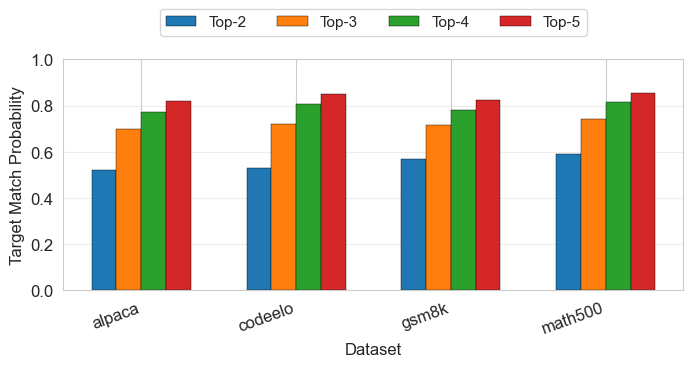

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_6_target_match_probability_k3.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_6_target_match_probability_k3.png


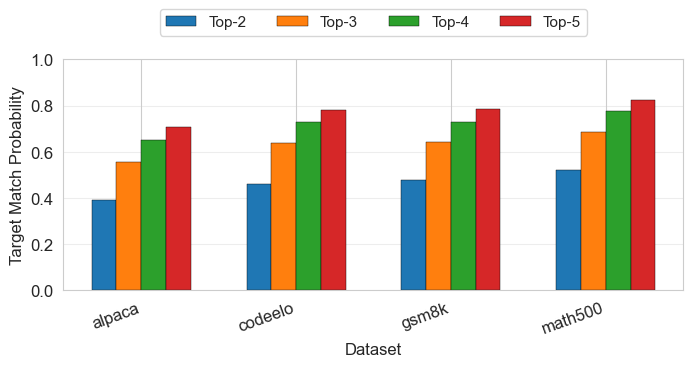

In [111]:
def plot_figure_6_target_match_probability():
    fig_name = "figure_6_target_match_probability"

    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_topk_inclusiveness"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == TOPK_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={TOPK_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        rows = []
        for _, row in df.iterrows():
            base = {
                "dataset": row["dataset"],
                "speculative_length": row["speculative_length"],
            }
            base.update(topk_dict_to_row(row["misspeculation_topk_inclusiveness"]))
            rows.append(base)

        prob_df = pd.DataFrame(rows)
        datasets = sorted_datasets(prob_df["dataset"].unique())

        topks = [f"top{k}_prob" for k in range(2, 6)]
        topk_labels = [f"Top-{k}" for k in range(2, 6)]

        x = np.arange(len(datasets))
        bar_width = 0.16
        colors = color_map(topk_labels)

        fig, ax = plt.subplots(figsize=FIGSIZE_TALL)

        for i, (col, label) in enumerate(zip(topks, topk_labels)):
            values = [
                prob_df.loc[prob_df["dataset"] == dataset, col].mean()
                for dataset in datasets
            ]
            positions = x - (bar_width * len(topks)) / 2 + i * bar_width + bar_width / 2
            ax.bar(
                positions,
                values,
                width=bar_width,
                label=label,
                color=colors[label],
                edgecolor="black",
                linewidth=0.3,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=20, ha="right")
        ax.set_xlabel("Dataset")
        ax.set_ylabel("Target Match Probability")
        ax.set_title(None)
        ax.set_ylim(0.0, 1.0)
        ax.set_yticks(np.arange(0.0, 1.01, 0.2))
        ax.grid(True, axis="y", alpha=0.35)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.25),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=11,
        )

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{TOPK_SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_6_target_match_probability()

## Figure 7. Misspeculation confidence correlation, top-1 confidence

[figure_7_misspeculation_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=alpaca, top1_confidence: q50=0.458074, q95=0.855076, num_misspec_samples=3087
[figure_7_misspeculation_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=codeelo, top1_confidence: q50=0.491659, q95=0.880351, num_misspec_samples=3063
[figure_7_misspeculation_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=gsm8k, top1_confidence: q50=0.464362, q95=0.907105, num_misspec_samples=1217
[figure_7_misspeculation_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=math500, top1_confidence: q50=0.489579, q95=0.899656, num_misspec_samples=1470
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_7_misspeculation_top1_confidence_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_7_misspeculation_top1_confidence_k3.png


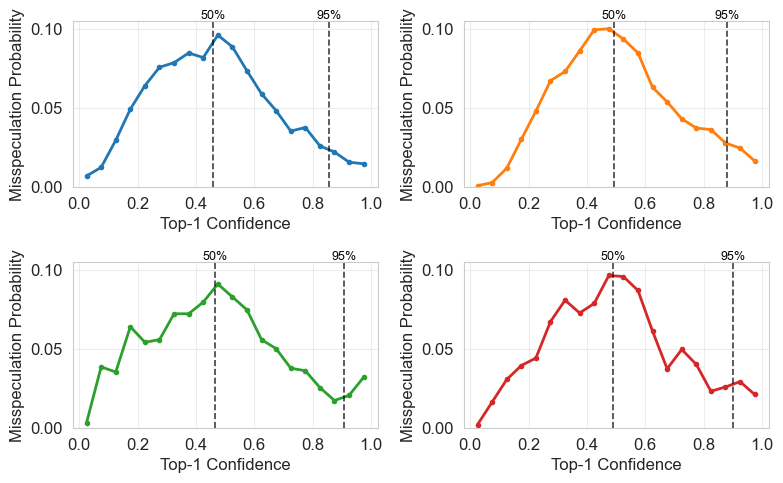

[figure_7_misspeculation_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=alpaca, top1_confidence: q50=0.456743, q95=0.886351, num_misspec_samples=7476
[figure_7_misspeculation_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=codeelo, top1_confidence: q50=0.472833, q95=0.868211, num_misspec_samples=5951
[figure_7_misspeculation_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=gsm8k, top1_confidence: q50=0.504627, q95=0.916208, num_misspec_samples=4447
[figure_7_misspeculation_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=math500, top1_confidence: q50=0.520412, q95=0.909837, num_misspec_samples=3120
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_7_misspeculation_top1_confidence_k3.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_7_misspeculation_top1_confidence_k3.png


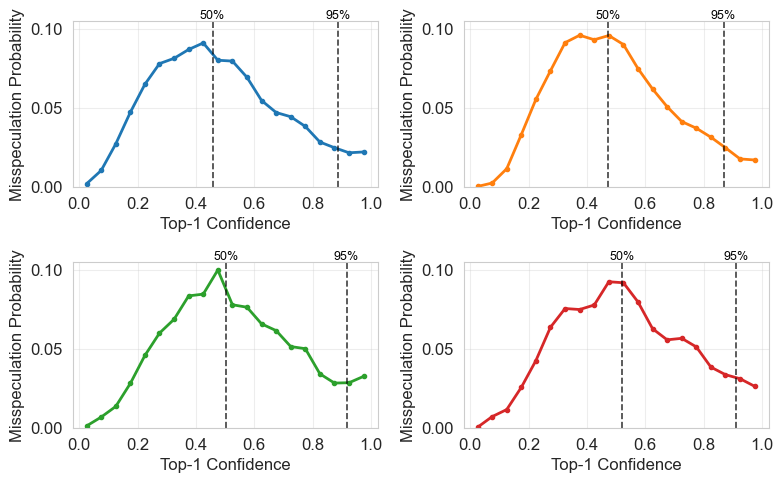

In [112]:
MISSPEC_CONF_THRESHOLDS = {}
def expand_confidence_rows(df, value_col):
    rows = []

    for _, row in df.iterrows():
        corr_rows = row.get("misspeculation_confidence_correlation")
        if not isinstance(corr_rows, list):
            continue

        for corr in corr_rows:
            if not isinstance(corr, dict):
                continue

            value = corr.get(value_col)
            if value is None:
                continue

            rows.append(
                {
                    "dataset": row["dataset"],
                    "method": row["method"],
                    "speculative_length": row["speculative_length"],
                    "value": value,
                }
            )

    return pd.DataFrame(rows)

def probability_hist_line(values, bins):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        centers = (bins[:-1] + bins[1:]) / 2.0
        return centers, np.zeros_like(centers)

    counts, edges = np.histogram(values, bins=bins)
    probs = counts / counts.sum() if counts.sum() > 0 else np.zeros_like(counts, dtype=float)
    centers = (edges[:-1] + edges[1:]) / 2.0

    return centers, probs

def plot_confidence_correlation_grid(value_col, xlabel, fig_name):
    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_confidence_correlation"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == CONF_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={CONF_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        long_df = expand_confidence_rows(df, value_col=value_col)
        if long_df.empty:
            print(f"[skip] {fig_name}: no confidence rows for {model_pair}")
            continue

        datasets = sorted_datasets(long_df["dataset"].unique())
        n = len(datasets)
        ncols = 2
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=FIGSIZE_GRID,
            sharex=True,
            sharey=True,
        )

        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])

        axes = axes.flatten()
        colors = color_map(datasets)

        if value_col == "residual_confidence":
            lo = min(0.0, float(long_df["value"].min()))
            hi = max(1.0, float(long_df["value"].max()))
            bins = np.linspace(lo, hi, 21)
        else:
            lo = 0.0
            hi = 1.0
            bins = np.linspace(lo, hi, 21)

        for i, dataset in enumerate(datasets):
            ax = axes[i]
            values = long_df.loc[long_df["dataset"] == dataset, "value"].dropna().values
            centers, probs = probability_hist_line(values, bins=bins)

            ax.plot(
                centers,
                probs,
                marker="o",
                linewidth=2,
                markersize=3,
                color=colors[dataset],
            )

            quantiles = {
                "50%": 0.50,
                "95%": 0.95,
            #    "99%": 0.99,
            }

            if len(values) > 0:
                q50 = np.quantile(values, 0.50)
                q95 = np.quantile(values, 0.95)

                MISSPEC_CONF_THRESHOLDS[(model_pair, dataset, value_col)] = {
                    "50%": q50,
                    "95%": q95,
                }

                print(
                    f"[{fig_name}] model_pair={model_pair}, "
                    f"dataset={dataset}, "
                    f"{value_col}: q50={q50:.6f}, q95={q95:.6f}, "
                    f"num_misspec_samples={len(values)}"
                )

                for q_label, q_value in MISSPEC_CONF_THRESHOLDS[(model_pair, dataset, value_col)].items():
                    ax.axvline(
                        q_value,
                        color="black",
                        linestyle="--",
                        linewidth=1.2,
                        alpha=0.75,
                    )
                    ax.text(
                        q_value,
                        1.07,
                        q_label,
                        transform=ax.get_xaxis_transform(),
                        va="top",
                        ha="center",
                        fontsize=9,
                        color="black",
                    )
            ax.set_title(None)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Misspeculation Probability")
            ax.grid(True, alpha=0.35)

            ax.tick_params(
                axis="both",
                which="both",
                labelbottom=True,
                labelleft=True,
            )

            ax.set_xticks(np.linspace(lo, hi, 6))
            ymax = float(np.nanmax(probs)) if len(probs) > 0 else 0.05
            ymax = np.ceil(ymax / 0.05) * 0.05
            ymax = max(ymax, 0.05)

            ax.set_ylim(0.0, ymax+0.005)
            ax.set_yticks(np.arange(0.0, ymax + 1e-9, 0.05))

        for j in range(len(datasets), len(axes)):
            axes[j].axis("off")

        fig.tight_layout()

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{CONF_SPECULATIVE_LENGTH}")
        plt.show()

plot_confidence_correlation_grid(
    value_col="top1_confidence",
    xlabel="Top-1 Confidence",
    fig_name="figure_7_misspeculation_top1_confidence",
)


## Figure 8. Misspeculation confidence correlation, residual confidence

[figure_8_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=alpaca, residual_confidence: q50=0.191079, q95=0.767299, num_misspec_samples=3087
[figure_8_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=codeelo, residual_confidence: q50=0.222055, q95=0.816524, num_misspec_samples=3063
[figure_8_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=gsm8k, residual_confidence: q50=0.181309, q95=0.837709, num_misspec_samples=1217
[figure_8_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=math500, residual_confidence: q50=0.174488, q95=0.836638, num_misspec_samples=1470
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_8_misspeculation_residual_confidence_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_8_misspeculation_residu

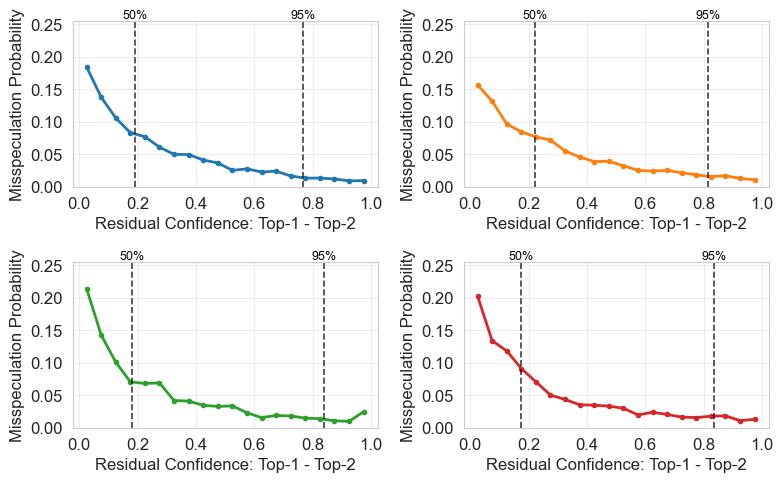

[figure_8_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=alpaca, residual_confidence: q50=0.211260, q95=0.827718, num_misspec_samples=7476
[figure_8_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=codeelo, residual_confidence: q50=0.215224, q95=0.795603, num_misspec_samples=5951
[figure_8_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=gsm8k, residual_confidence: q50=0.239450, q95=0.869176, num_misspec_samples=4447
[figure_8_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=math500, residual_confidence: q50=0.240832, q95=0.859051, num_misspec_samples=3120
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_8_misspeculation_residual_confidence_k3.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_8_misspeculation_residual_confidence_k3.png


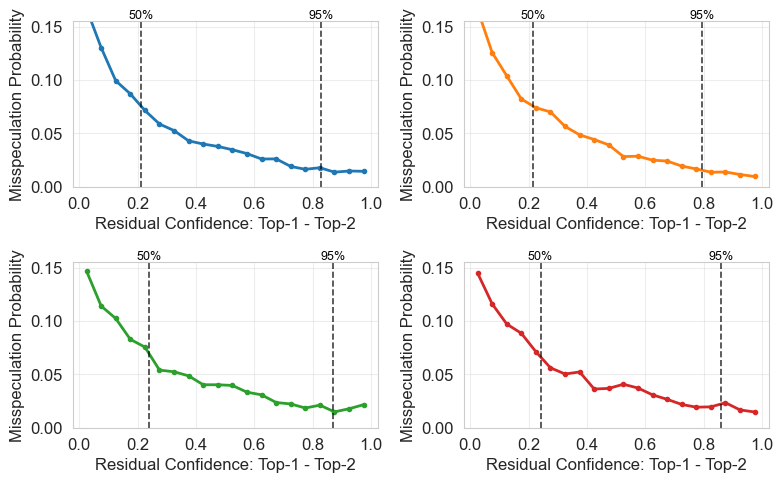

In [113]:
plot_confidence_correlation_grid(
    value_col="residual_confidence",
    xlabel="Residual Confidence: Top-1 - Top-2",
    fig_name="figure_8_misspeculation_residual_confidence",
)


[figure_9_sampling_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=alpaca, top1_confidence, misspec_50%_threshold=0.458074: sampling_prob=0.123175, sampling_percent=12.32%, num_sampling_samples=20272
[figure_9_sampling_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=alpaca, top1_confidence, misspec_95%_threshold=0.855076: sampling_prob=0.363457, sampling_percent=36.35%, num_sampling_samples=20272
[figure_9_sampling_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=codeelo, top1_confidence, misspec_50%_threshold=0.491659: sampling_prob=0.129889, sampling_percent=12.99%, num_sampling_samples=20325
[figure_9_sampling_top1_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=codeelo, top1_confidence, misspec_95%_threshold=0.880351: sampling_prob=0.398622, sampling_percent=39.86%, num_sampling_samples=20325
[figure_9_sampling_top1_confidence] model_pair=Llama-3.3-70B-I

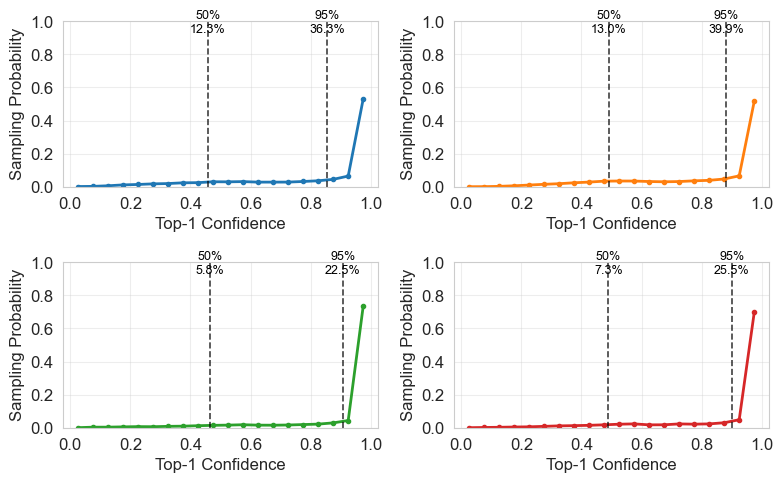

[figure_9_sampling_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=alpaca, top1_confidence, misspec_50%_threshold=0.456743: sampling_prob=0.217131, sampling_percent=21.71%, num_sampling_samples=25054
[figure_9_sampling_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=alpaca, top1_confidence, misspec_95%_threshold=0.886351: sampling_prob=0.578271, sampling_percent=57.83%, num_sampling_samples=25054
[figure_9_sampling_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=codeelo, top1_confidence, misspec_50%_threshold=0.472833: sampling_prob=0.191606, sampling_percent=19.16%, num_sampling_samples=23517
[figure_9_sampling_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=codeelo, top1_confidence, misspec_95%_threshold=0.868211: sampling_prob=0.540077, sampling_percent=54.01%, num_sampling_samples=23517
[figure_9_sampling_top1_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=gsm8k, top1_confidence, misspec_50%_threshold=0.504627: sampling_prob=0.152999, s

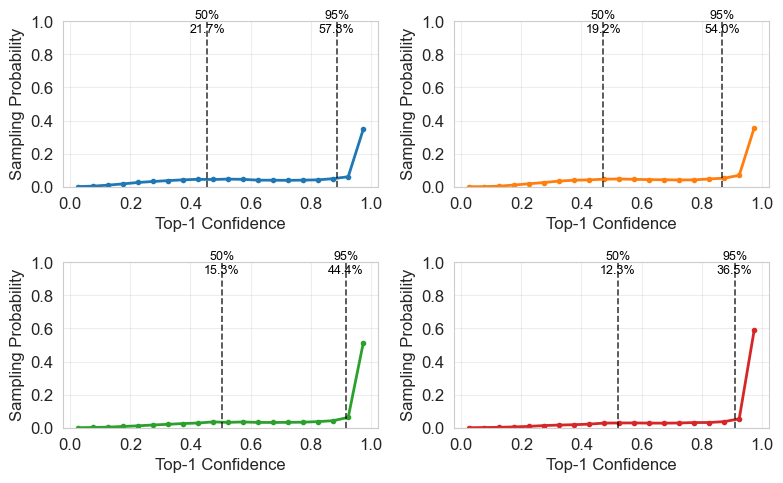

In [114]:
def expand_sampling_confidence_rows(df, value_col):
    rows = []

    for _, row in df.iterrows():
        dist_rows = row.get("confidence_distribution")
        if not isinstance(dist_rows, list):
            continue

        for dist in dist_rows:
            if not isinstance(dist, dict):
                continue

            value = dist.get(value_col)
            if value is None:
                continue

            rows.append(
                {
                    "dataset": row["dataset"],
                    "method": row["method"],
                    "speculative_length": row["speculative_length"],
                    "value": value,
                }
            )

    return pd.DataFrame(rows)


def plot_sampling_confidence_distribution_grid(value_col, xlabel, fig_name):
    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "confidence_distribution"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == CONF_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={CONF_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        long_df = expand_sampling_confidence_rows(df, value_col=value_col)
        if long_df.empty:
            print(f"[skip] {fig_name}: no confidence distribution rows for {model_pair}")
            continue

        datasets = sorted_datasets(long_df["dataset"].unique())
        n = len(datasets)
        ncols = 2
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=FIGSIZE_GRID,
            sharex=True,
            sharey=True,
        )

        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])

        axes = axes.flatten()
        colors = color_map(datasets)

        if value_col == "residual_confidence":
            lo = min(0.0, float(long_df["value"].min()))
            hi = max(1.0, float(long_df["value"].max()))
            bins = np.linspace(lo, hi, 21)
        else:
            lo = 0.0
            hi = 1.0
            bins = np.linspace(lo, hi, 21)

        for i, dataset in enumerate(datasets):
            ax = axes[i]
            values = long_df.loc[long_df["dataset"] == dataset, "value"].dropna().values
            centers, probs = probability_hist_line(values, bins=bins)

            ax.plot(
                centers,
                probs,
                marker="o",
                linewidth=2,
                markersize=3,
                color=colors[dataset],
            )

            # quantiles = {
            #     "50%": 0.50,
            #     "95%": 0.95,
            # }

            # if len(values) > 0:
            #     for q_label, q in quantiles.items():
            #         q_value = np.quantile(values, q)
            #         ax.axvline(
            #             q_value,
            #             color="black",
            #             linestyle="--",
            #             linewidth=1.2,
            #             alpha=0.75,
            #         )
            #         ax.text(
            #             q_value,
            #             1.07,
            #             q_label,
            #             transform=ax.get_xaxis_transform(),
            #             va="top",
            #             ha="center",
            #             fontsize=9,
            #             color="black",
            #         )

            key = (model_pair, dataset, value_col)
            if key in MISSPEC_CONF_THRESHOLDS and len(values) > 0:
                for q_label, q_value in MISSPEC_CONF_THRESHOLDS[key].items():
                    sampling_prob = np.mean(values <= q_value)

                    print(
                        f"[{fig_name}] model_pair={model_pair}, "
                        f"dataset={dataset}, "
                        f"{value_col}, misspec_{q_label}_threshold={q_value:.6f}: "
                        f"sampling_prob={sampling_prob:.6f}, "
                        f"sampling_percent={sampling_prob * 100:.2f}%, "
                        f"num_sampling_samples={len(values)}"
                    )

                    ax.axvline(
                        q_value,
                        color="black",
                        linestyle="--",
                        linewidth=1.2,
                        alpha=0.75,
                    )
                    ax.text(
                        q_value,
                        1.07,
                        f"{q_label}\n{sampling_prob * 100:.1f}%",
                        transform=ax.get_xaxis_transform(),
                        va="top",
                        ha="center",
                        fontsize=9,
                        color="black",
                    )

            ax.set_title(None)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Sampling Probability")
            ax.grid(True, alpha=0.35)
            

            ax.tick_params(
                axis="both",
                which="both",
                labelbottom=True,
                labelleft=True,
            )

            ax.set_xticks(np.linspace(lo, hi, 6))
            ax.set_ylim(0.0, 1.0)
            ax.set_yticks(np.arange(0.0, 1.01, 0.2))

        for j in range(len(datasets), len(axes)):
            axes[j].axis("off")

        fig.tight_layout()

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{CONF_SPECULATIVE_LENGTH}")
        plt.show()


plot_sampling_confidence_distribution_grid(
    value_col="top1_confidence",
    xlabel="Top-1 Confidence",
    fig_name="figure_9_sampling_top1_confidence",
)



[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=alpaca, residual_confidence, misspec_50%_threshold=0.191079: sampling_prob=0.124309, sampling_percent=12.43%, num_sampling_samples=20272
[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=alpaca, residual_confidence, misspec_95%_threshold=0.767299: sampling_prob=0.360251, sampling_percent=36.03%, num_sampling_samples=20272
[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=codeelo, residual_confidence, misspec_50%_threshold=0.222055: sampling_prob=0.136187, sampling_percent=13.62%, num_sampling_samples=20325
[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=codeelo, residual_confidence, misspec_95%_threshold=0.816524: sampling_prob=0.405018, sampling_percent=40.50%, num_sampling_samples=20325
[figure_10_sampling_residu

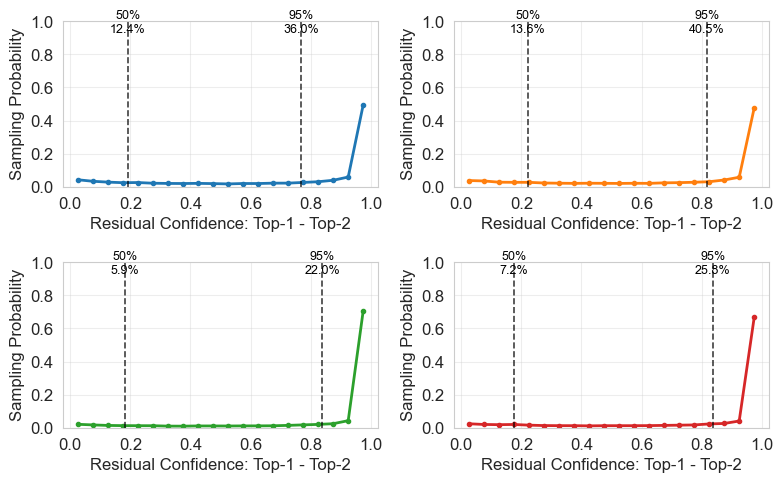

[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=alpaca, residual_confidence, misspec_50%_threshold=0.211260: sampling_prob=0.222519, sampling_percent=22.25%, num_sampling_samples=25054
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=alpaca, residual_confidence, misspec_95%_threshold=0.827718: sampling_prob=0.580905, sampling_percent=58.09%, num_sampling_samples=25054
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=codeelo, residual_confidence, misspec_50%_threshold=0.215224: sampling_prob=0.199558, sampling_percent=19.96%, num_sampling_samples=23517
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=codeelo, residual_confidence, misspec_95%_threshold=0.795603: sampling_prob=0.544202, sampling_percent=54.42%, num_sampling_samples=23517
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=gsm8k, residual_confidence, misspec_50%_

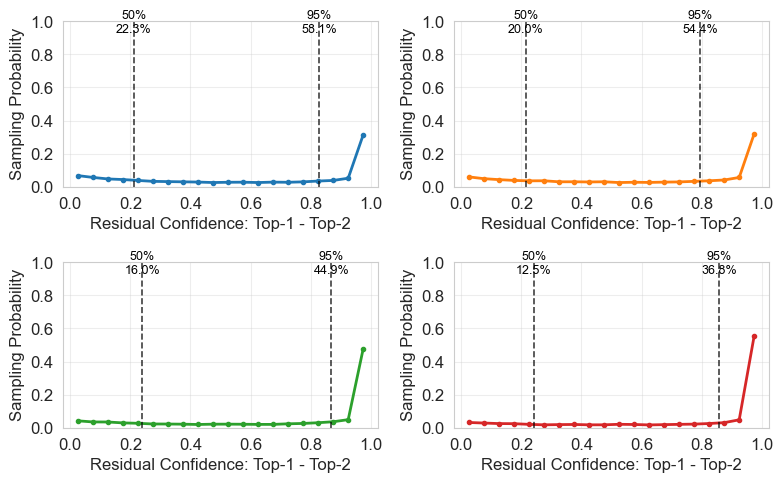

In [115]:
plot_sampling_confidence_distribution_grid(
    value_col="residual_confidence",
    xlabel="Residual Confidence: Top-1 - Top-2",
    fig_name="figure_10_sampling_residual_confidence",
)

## Raw dataframe previews

In [116]:

display(motivation_df.head())
display(results_df.head())
display(insight_df.head())
display(trace_df.head())

,method,batch_size,speculative_length,target_model,draft_model,temperature,dataset,run_dir,avg_target_accept_len,avg_intermediate_accept_len,...,misspeculation_rounds,misspeculation_probability,accept_rate_per_position,accept_length_per_round,accept_distribution_rounds,target_batch_accept_distributions,spec_policy,speculate_k,method_pretty,model_pair
0,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/metadata/hierarchical/b16/k3/Llama-3.3...,5.265264,2.480617,...,6150,0.073379,"{'0': 0.9266206106596986, '1': 0.8631086611542...","{'0': 0.07337938934030139, '1': 0.063511949505...",83811,"{'0': 0.07310468259230031, '1': 0.063108170500...",hierarchical,3,Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
1,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,alpaca,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,4.879260,NaN,...,2174,0.193434,"{'0': 0.8065664205000445, '1': 0.6726577097606...","{'0': 0.19343357949995552, '1': 0.133908710739...",11239,"{'0': 0.19218493989410312, '1': 0.130882270673...",default,11,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
2,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,codeelo,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,4.967431,NaN,...,1979,0.178546,"{'0': 0.8214543486106098, '1': 0.6781847708408...","{'0': 0.1785456513893901, '1': 0.1432695777697...",11084,"{'0': 0.17766828573725127, '1': 0.143305305805...",default,11,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
3,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,gsm8k,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,7.551092,NaN,...,786,0.101537,"{'0': 0.8984627309133187, '1': 0.8327089523317...","{'0': 0.10153726908668131, '1': 0.065753778581...",7741,"{'0': 0.1073106867783675, '1': 0.0671336241916...",default,11,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
4,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,math500,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,7.047156,NaN,...,923,0.112178,"{'0': 0.8878220709771512, '1': 0.8028682547399...","{'0': 0.1121779290228488, '1': 0.0849538162372...",8228,"{'0': 0.1097097009947478, '1': 0.0838826516162...",default,11,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct


,method,batch_size,speculative_length,target_model,draft_model,temperature,dataset,run_dir,execution_wall_time_s,prefill_wall_time_s,...,hv_avg_verify_batch_size_intermediate,hv_avg_verify_batch_size_target,avg_draft_time_per_batch,avg_intermediate_verification_time_per_batch,avg_target_verification_time_per_batch,avg_before_expansion_batch_size,avg_after_expansion_batch_size,expansion_ratio,method_pretty,model_pair
1,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/cost/hierarchical/b16/k3/Llama-3.3-70B...,47.980261,5.365289,...,14.771700,14.771700,0.008508,0.008215,0.025159,NaN,NaN,NaN,Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
2,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/cost/hierarchical/b16/k3/Llama-3.3-70B...,50.515219,7.843179,...,15.417910,15.417910,0.009026,0.008685,0.025990,NaN,NaN,NaN,Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
3,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/cost/hierarchical/b16/k3/Llama-3.3-70B...,36.965265,4.353334,...,15.016794,15.016794,0.008170,0.008056,0.025098,NaN,NaN,NaN,Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
4,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/cost/hierarchical/b16/k3/Llama-3.3-70B...,44.352504,4.848583,...,14.539948,14.539948,0.008629,0.008147,0.025189,NaN,NaN,NaN,Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
5,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/cost/hierarchical/b16/k3/Llama-3.3-70B...,38.931918,4.408119,...,15.447605,15.447605,0.008627,0.008362,0.025742,NaN,NaN,NaN,Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct


,method,batch_size,speculative_length,target_model,draft_model,temperature,dataset,run_dir,num_metadata_rows,num_misspeculation_steps,misspeculation_topk_inclusiveness,misspeculation_confidence_correlation,confidence_distribution,method_pretty,model_pair
0,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/metadata/hierarchical/b16/k3/Llama-3.3...,167622,6150,"{'num_misspeculation_steps': 6150, 'top1': 173...","[{'step_id': 2, 'request_id': 7, 'top1_confide...","[{'step_id': 1, 'request_id': 6, 'verification...",Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
1,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,alpaca,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,11239,2174,"{'num_misspeculation_steps': 2174, 'top1': 16,...","[{'step_id': 1, 'request_id': 5, 'top1_confide...","[{'step_id': 1, 'request_id': 4, 'verification...",Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
2,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,codeelo,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,11084,1979,"{'num_misspeculation_steps': 1979, 'top1': 16,...","[{'step_id': 1, 'request_id': 4, 'top1_confide...","[{'step_id': 1, 'request_id': 4, 'verification...",Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
3,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,gsm8k,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,7741,786,"{'num_misspeculation_steps': 786, 'top1': 6, '...","[{'step_id': 1, 'request_id': 4, 'top1_confide...","[{'step_id': 1, 'request_id': 4, 'verification...",Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
4,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,math500,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,8228,923,"{'num_misspeculation_steps': 923, 'top1': 6, '...","[{'step_id': 1, 'request_id': 8, 'top1_confide...","[{'step_id': 1, 'request_id': 4, 'verification...",Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct


,method,batch_size,speculative_length,target_model,draft_model,temperature,dataset,run_dir,request_start,request_end,step_start,step_end,target_accept_len_by_request,duplicate_target_accept_len_rows_ignored,method_pretty,model_pair
0,hierarchical,16,3,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,r1,results/metadata/hierarchical/b16/k3/Llama-3.3...,4,14,1,20,"{'request_4': [None, None, None, None, None, N...",0,Hierarchical Verification,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
1,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,alpaca,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,4,14,1,20,"{'request_4': [2, 3, 0, 2, 9, 2, 4, 1, 0, 4, 2...",0,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
2,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,codeelo,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,4,14,1,20,"{'request_4': [0, 4, 1, 4, 6, 11, 2, 11, 11, 5...",0,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
3,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,gsm8k,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,4,14,1,20,"{'request_4': [0, 0, 0, 0, 9, 0, 1, 2, 1, 5, 1...",0,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
4,sync,16,11,Llama-3.3-70B-Instruct,Llama-3.2-1B-Instruct,0,math500,results/metadata/sync/b16/k11/Llama-3.3-70B-In...,4,14,1,20,"{'request_4': [9, 11, 3, 11, 11, 11, 8, 7, 4, ...",0,Speculative Decoding,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
